# Visualize nuScenes Boxes on Point Clouds

This notebook loads a nuScenes sample, converts prediction boxes from a `results_nusc.json` file back into LiDAR coordinates, and renders them with the repo's Open3D visualizer.

If you want to inspect ground truth too, set `SHOW_GT = True` in the config cell.

In [16]:
import json
import sys
from pathlib import Path

import numpy as np
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import Box
from pyquaternion import Quaternion

ROOT_DIR = Path("/OpenPCDet")
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
if str(ROOT_DIR / "tools") not in sys.path:
    sys.path.insert(0, str(ROOT_DIR / "tools"))

from visual_utils.open3d_vis_utils import draw_scenes

In [17]:
# Update these paths for your run.
NUSC_ROOT = Path("/OpenPCDet/datasets/nuscenes/")
VERSION = "v1.0-mini"

RESULTS_JSON = Path("/OpenPCDet/output/OpenPCDet/tools/cfgs/custom_models/second/default/second_nuscenes/SECOND_nuscenes_non_retrained/eval/epoch_7862/test/default/final_result/data/results_nusc.json")
SAMPLE_TOKEN = "bebf5f5b2a674631ab5c88fd1aa9e87a"  # Leave empty to use the first sample in RESULTS_JSON.
SHOW_GT = False
MAX_POINTS = 120000
RANDOM_SEED = 0

In [18]:
import numpy as np
from nuscenes.utils.data_classes import Box
from pyquaternion import Quaternion

_original_rotate = Box.rotate

def _safe_rotate(self, quaternion):
    # Ensure velocity is 3D before rotation
    if self.velocity is not None and len(self.velocity) == 2:
        self.velocity = np.array([self.velocity[0], self.velocity[1], 0.0])
    _original_rotate(self, quaternion)

Box.rotate = _safe_rotate

In [19]:
def resolve_sample_token(nusc, token, results_keys=None):
    token = (token or "").strip()
    if not token:
        raise ValueError("A non-empty token is required.")

    if token in nusc._token2ind["sample"]:
        return token

    if token in nusc._token2ind["scene"]:
        scene = nusc.get("scene", token)
        candidate = scene["first_sample_token"]

        if results_keys is not None:
            keys = set(results_keys)
            current = candidate
            while current:
                if current in keys:
                    return current
                current = nusc.get("sample", current)["next"]

        return candidate

    raise KeyError(
        f"Token '{token}' is neither a sample token nor a scene token in this NuScenes split."
    )


def load_lidar_points(nusc, sample_token):
    sample = nusc.get("sample", sample_token)
    lidar_token = sample["data"]["LIDAR_TOP"]
    lidar_path = nusc.get_sample_data_path(lidar_token)
    points = np.fromfile(lidar_path, dtype=np.float32).reshape(-1, 5)[:, :4]
    return points


def sample_box_to_lidar_box(nusc, sample_token, sample_box):
    sample = nusc.get("sample", sample_token)
    lidar_token = sample["data"]["LIDAR_TOP"]
    sd = nusc.get("sample_data", lidar_token)
    cs = nusc.get("calibrated_sensor", sd["calibrated_sensor_token"])
    pose = nusc.get("ego_pose", sd["ego_pose_token"])

    raw_vel = sample_box.get("velocity", [0.0, 0.0])
    velocity_3d = (float(raw_vel[0]), float(raw_vel[1]), 0.0)  # pad with vz=0

    box = Box(
        sample_box["translation"],
        sample_box["size"],
        Quaternion(sample_box["rotation"]),
        label=0,
        score=float(sample_box.get("detection_score", 0.0)),
        velocity=velocity_3d,
    )

    box.translate(-np.array(pose["translation"]))
    box.rotate(Quaternion(pose["rotation"]).inverse)
    box.translate(-np.array(cs["translation"]))
    box.rotate(Quaternion(cs["rotation"]).inverse)

    yaw = box.orientation.yaw_pitch_roll[0]
    return np.array([box.center[0], box.center[1], box.center[2], box.wlh[1], box.wlh[0], box.wlh[2], yaw], dtype=np.float32)


def load_prediction_boxes(nusc, results_json_path, sample_token):
    data = json.loads(results_json_path.read_text())
    records = data["results"].get(sample_token, [])
    boxes = np.stack([sample_box_to_lidar_box(nusc, sample_token, record) for record in records], axis=0) if records else np.zeros((0, 7), dtype=np.float32)
    scores = np.array([float(record.get("detection_score", 0.0)) for record in records], dtype=np.float32) if records else np.zeros((0,), dtype=np.float32)
    names = [record.get("detection_name", "") for record in records]
    return boxes, scores, names


def load_ground_truth_boxes(nusc, sample_token):
    sample = nusc.get("sample", sample_token)
    gt_boxes = []
    for ann_token in sample["anns"]:
        ann = nusc.get("sample_annotation", ann_token)
        box = Box(ann["translation"], ann["size"], Quaternion(ann["rotation"]))

        lidar_token = sample["data"]["LIDAR_TOP"]
        sd = nusc.get("sample_data", lidar_token)
        cs = nusc.get("calibrated_sensor", sd["calibrated_sensor_token"])
        pose = nusc.get("ego_pose", sd["ego_pose_token"])

        box.translate(-np.array(pose["translation"]))
        box.rotate(Quaternion(pose["rotation"]).inverse)
        box.translate(-np.array(cs["translation"]))
        box.rotate(Quaternion(cs["rotation"]).inverse)

        gt_boxes.append(np.array([box.center[0], box.center[1], box.center[2], box.wlh[1], box.wlh[0], box.wlh[2], box.orientation.yaw_pitch_roll[0]], dtype=np.float32))

    return np.stack(gt_boxes, axis=0) if gt_boxes else np.zeros((0, 7), dtype=np.float32)

In [20]:
nusc = NuScenes(version=VERSION, dataroot=str(NUSC_ROOT), verbose=True)
results_path = RESULTS_JSON
assert results_path.exists(), f"Missing results file: {results_path}"

results_data = json.loads(results_path.read_text())
results_keys = results_data.get("results", {}).keys()
assert results_keys, "results_json has no predictions under 'results'."

requested_token = SAMPLE_TOKEN or next(iter(results_keys))
sample_token = resolve_sample_token(nusc, requested_token, results_keys=results_keys)
if requested_token != sample_token:
    print(f"Resolved '{requested_token}' to sample token '{sample_token}'.")

points = load_lidar_points(nusc, sample_token)
if len(points) > MAX_POINTS:
    rng = np.random.default_rng(RANDOM_SEED)
    indices = rng.choice(len(points), size=MAX_POINTS, replace=False)
    points = points[indices]

pred_boxes, pred_scores, pred_names = load_prediction_boxes(nusc, results_path, sample_token)
print(f"sample_token: {sample_token}")
print(f"points: {points.shape[0]}")
print(f"predictions: {len(pred_boxes)}")

try:
    if SHOW_GT:
        gt_boxes = load_ground_truth_boxes(nusc, sample_token)
        print(f"ground truth boxes: {len(gt_boxes)}")
        draw_scenes(points, gt_boxes=gt_boxes, ref_boxes=pred_boxes, ref_scores=pred_scores)
    else:
        draw_scenes(points, ref_boxes=pred_boxes, ref_scores=pred_scores)
except Exception as exc:
    print(f"Visualization skipped: {exc}")

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.4 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
Resolved 'bebf5f5b2a674631ab5c88fd1aa9e87a' to sample token '5991fad3280c4f84b331536c32001a04'.
sample_token: 5991fad3280c4f84b331536c32001a04
points: 34368
predictions: 0
[Open3D WARNING] GLFW Error: GLX: Failed to create context: BadValue (integer parameter out of range for operation)
[Open3D WARNING] Failed to create window
Visualization skipped: 'NoneType' object has no attribute 'point_size'


In [21]:


%matplotlib inline

from nuscenes import NuScenes

nusc = NuScenes(version='v1.0-mini', dataroot='/OpenPCDet/datasets/nuscenes', verbose=True)



Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.2 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [22]:
nusc.list_attributes()

cycle.with_rider: 305
cycle.without_rider: 434
pedestrian.moving: 3875
pedestrian.sitting_lying_down: 111
pedestrian.standing: 1029
vehicle.moving: 2715
vehicle.parked: 4674
vehicle.stopped: 1545


In [23]:
my_sample = nusc.sample[87]

In [24]:
# show the sample record for the current sample token
sample = nusc.get("sample", my_sample["token"])
print(sample)

{'token': '6dabc0fb1df045558f802246dd186b3f', 'timestamp': 1535489300046941, 'prev': 'b7f64f73e8a548488e6d85d9b0e13242', 'next': '82597244941b4e79aa3e1e9cc6386f8b', 'scene_token': '6f83169d067343658251f72e1dd17dbc', 'data': {'RADAR_FRONT': '020ecc01ab674ebabd3efbeb651800a8', 'RADAR_FRONT_LEFT': '8608ece15310417183a4ce928acc9d92', 'RADAR_FRONT_RIGHT': '7900c7855d7f41e99c047b08fac73f07', 'RADAR_BACK_LEFT': 'e7fa0148f1554603b19ce1c2f98dd629', 'RADAR_BACK_RIGHT': '7c1c8f579be9458fa5ac2f48d001ecf3', 'LIDAR_TOP': 'd219ffa9b4ce492c8b8059db9d8b3166', 'CAM_FRONT': '435543e1321b411ea5c930633e0883d9', 'CAM_FRONT_RIGHT': '12ed78f3bf934630a952f3259861877a', 'CAM_BACK_RIGHT': '3486d5847c244722a8ed7d943d8b9200', 'CAM_BACK': '365e64003ab743b3ae9ffc7ddb68872f', 'CAM_BACK_LEFT': '20a0bc8f862d456b8bf27be30dbbb8dc', 'CAM_FRONT_LEFT': '31ff0404d9d941d7870f9942180f67c7'}, 'anns': ['cc2956dbf55b4e8cb65e61189266f14f', '4843546cff85496894aa43d04362c435', '58bcc697992b42e3aacaf9159593e893', 'cba7f06994cb4b708db

RecursionError: maximum recursion depth exceeded while calling a Python object

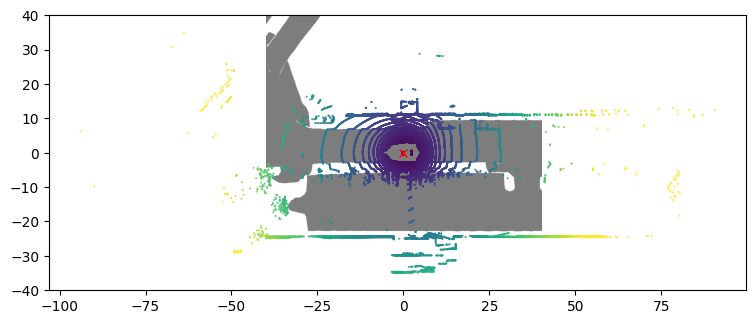

In [25]:
sample_data_token = nusc.get("sample", sample_token)["data"]["LIDAR_TOP"]
out_path = ROOT_DIR / "output" / "inspect_nuscenes_boxes_sample_data.png"

try:
    nusc.render_sample_data(sample_data_token,
                            with_anns=False,
                            out_path=str(out_path))
    print(f"saved: {out_path}")
except FileNotFoundError as exc:
    print(f"Skipping render because the lidar file is missing: {exc}")